In [13]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from typing import Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import random_split
import torch.nn.functional as F

In [14]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3438565731048584, 0.38001102209091187, 0.40772172808647156],
        std=[0.09119409322738647, 0.06507623195648193, 0.055207207798957825]
    )
])

all_dataset = datasets.ImageFolder(root='EuroSAT/2750/', transform=transform)



train_size = int(0.8 * len(all_dataset))
test_size = len(all_dataset) - train_size

train_dataset, test_dataset = random_split(
    all_dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

classes = all_dataset.classes


train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=256, shuffle=False, pin_memory=True)



In [16]:

# mean = torch.zeros(3)
# std = torch.zeros(3)
# total = 0

# for images, labels in train_loader :
#     batch_samples = images.size(0)
#     images = images.view(batch_samples, 3, -1)

#     mean += images.mean(2).sum(0)
#     std += images.std(2).sum(0)
#     total += batch_samples

# mean /= total
# std /= total

# print(f"Mean: {mean.tolist()}")
# print(f"Std:  {std.tolist()}")


In [ ]:
class CosineComponent(nn.Module):
    
    def __init__(self, emb_size, output_classes):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(emb_size, output_classes))
        nn.init.kaiming_uniform_(self.W)

    def forward(self, x):
        # Step 1:
        x_norm = F.normalize(x)
        W_norm = F.normalize(self.W, dim=0)
        # Step 2:
        return x_norm @ W_norm

class ArcFaceModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # извлекает признаки
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        
        # сжимает до 128
        self.embedding = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        # для обучения с ArcFace
        self.cosine_component = CosineComponent(128, 10)

    def forward(self, x, return_embedding=False):
        x = self.backbone(x)
        emb = self.embedding(x)
        
        if return_embedding:
            # Для t-SNE: возвращаем нормализованный эмбеддинг
            return F.normalize(emb, dim=1)
        
        # Для обучения: возвращаем косинусы для ArcFace loss
        return self.cosine_component(emb)

In [18]:

def arcface_loss(cosine, target, m=.4):
    # this prevents nan when a value slightly crosses 1.0 due to numerical error
    cosine = cosine.clip(-1+1e-7, 1-1e-7) 
    # Step 3:
    arcosine = cosine.arccos()
    # Step 4:
    arcosine += F.one_hot(target, 10) * m
    # Step 5:
    cosine2 = arcosine.cos()
    # Step 6:
    return F.cross_entropy(cosine2, target)

In [19]:
model =  ArcFaceModel().to(device)
opt = optim.Adam(model.parameters())

def train_step() -> float:
    model.train()
    
    running_loss = 0.
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Удаляем накопленные ранее градиенты.
        # parameter.grad = 0
        opt.zero_grad()
        
        # Делаем проход (forward pass).
        # Состояние модели `train` обеспечивает сохранение промежуточных результатов вычислений.
        # Эти сохраненные значения будут использованы ниже для вычисления градиента функции потерь.
        output = model(images)
        
        # Вычисляем функцию потерь на основе предсказания модели.
        loss = arcface_loss(output, labels)

        # Вычисляем градиент: направление, в котором функция потерь возрастает максимально быстро.
        # parameter.grad += dloss / dparameter
        loss.backward()

        # parameter += -lr * parameter.grad
        # 
        # PyTorch SGD:
        # velocity = momentum * velocity + parameter.grad
        # parameter += - lr * velocity
        opt.step()
        
        # Накапливаем статистику.
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


def test_step() -> Tuple[float, float]:
    model.eval()

    correct_total = 0.
    running_loss = 0.
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            
            prediction = output.max(  # [bs, num_classes] -> [bs, 1]
                dim=1,
                keepdim=True,
            )[1] # # .argmax(dim=1)
            correct_total += prediction.eq(labels.view_as(prediction)).sum()
            
            loss = arcface_loss(output, labels)
            running_loss += loss
        
    valid_loss = running_loss / len(test_loader)
    accuracy = correct_total / len(test_loader.dataset)
    return valid_loss.item(), accuracy.item()

In [20]:
train_losses = []
valid_losses = []
valid_accs = []

epochs = 20
model.to(device)

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step()
    valid_loss, valid_acc = test_step()
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    
    pbar.set_description(f'Avg. train/valid loss: {train_loss:.4f}/{valid_loss:.4f}')

Avg. train/valid loss: 1.5796/1.6055: 100%|██████████| 20/20 [02:38<00:00,  7.90s/it]


Text(0, 0.5, 'Loss')

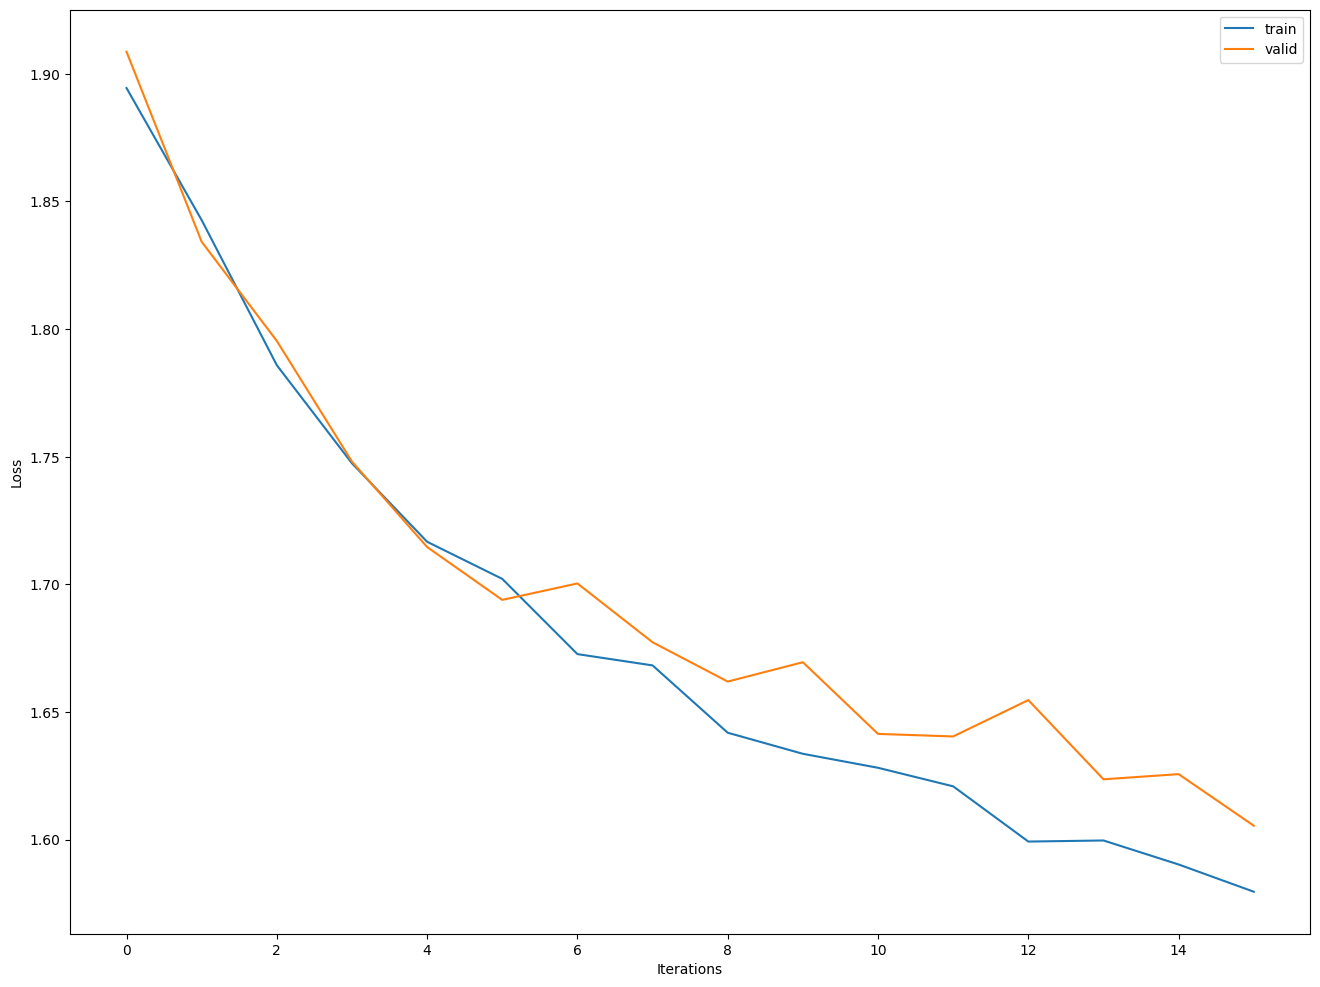

In [21]:
fig = plt.figure(figsize=(16, 12))

plt.plot(train_losses[4:], label='train')
plt.plot(valid_losses[4:], label='valid')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

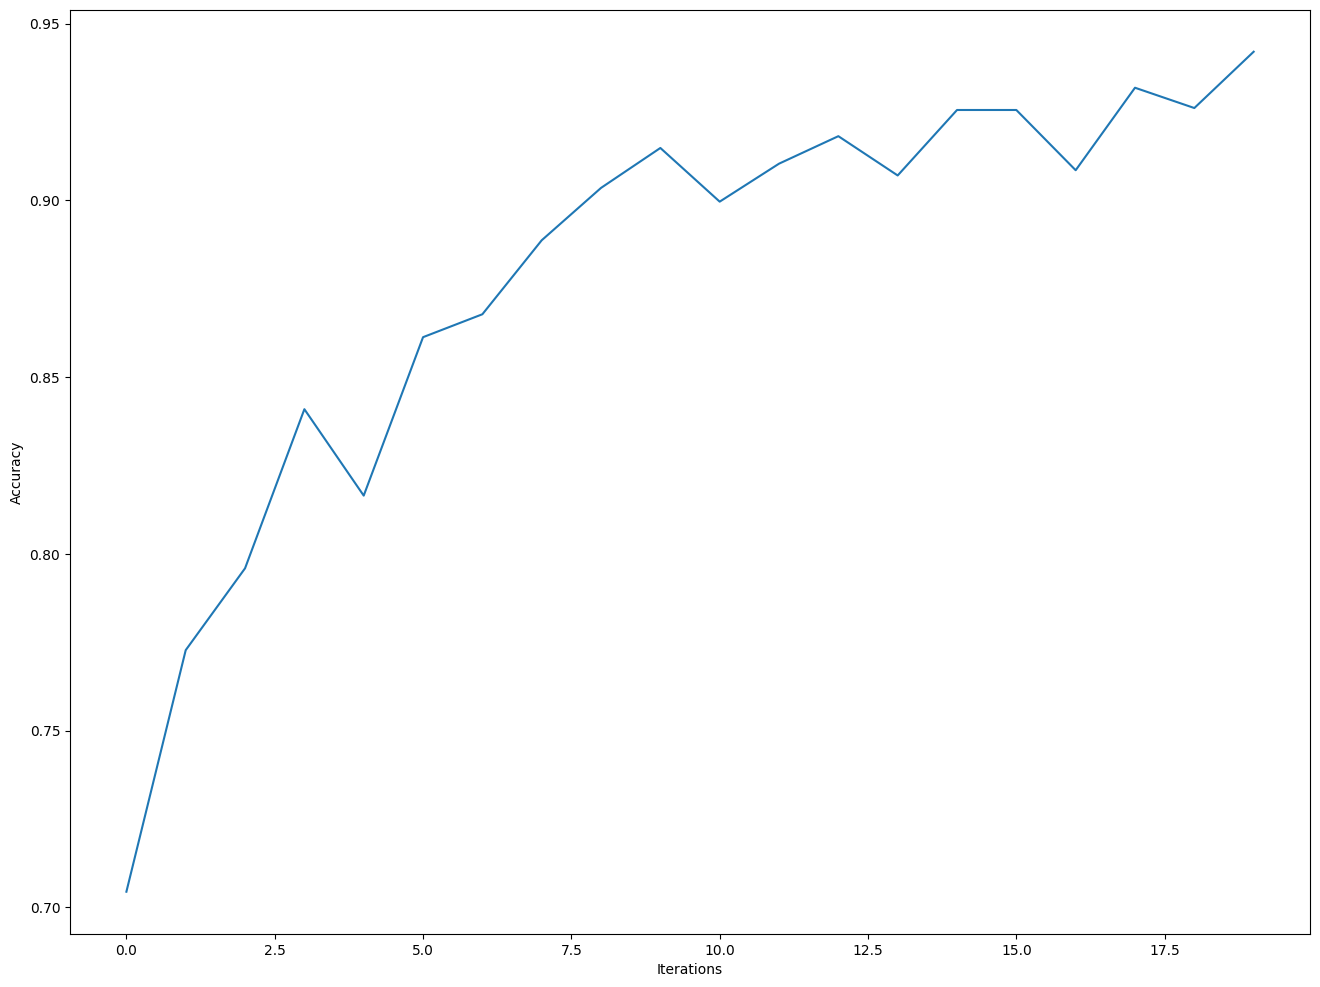

In [22]:
fig = plt.figure(figsize=(16, 12))

plt.plot(valid_accs)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')

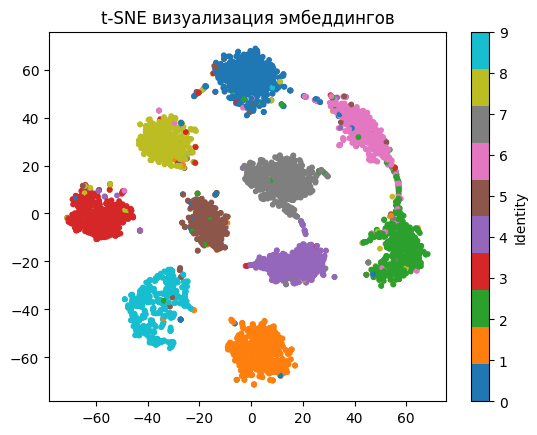

In [23]:
from sklearn.manifold import TSNE
import numpy as np

model.eval()
embeddings = []
labels_true = []

with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        emb = model(img, return_embedding=True)
        embeddings.append(emb.cpu().numpy())
        labels_true.extend(label.numpy())

embeddings = np.vstack(embeddings)
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_true, cmap='tab10', s=10)
plt.colorbar(label='Identity')
plt.title('t-SNE визуализация эмбеддингов')
plt.show()